# Análisis Exploratorio

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', 100)

df = pd.read_csv('data/train.csv') 
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,255,20,RL,70.0,8400,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,5,6,1957,1957,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,Gd,CBlock,TA,TA,No,Rec,922,Unf,0,392,1314,GasA,TA,Y,SBrkr,1314,0,0,1314,1,0,1,0,3,1,TA,5,Typ,0,NaN,Attchd,1957.0,RFn,1,294,TA,TA,Y,250,0,0,0,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal,145000
1,1067,60,RL,59.0,7837,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,7,1993,1994,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,Gd,TA,PConc,Gd,TA,No,Unf,0,Unf,0,799,799,GasA,Gd,Y,SBrkr,799,772,0,1571,0,0,2,1,3,1,TA,7,Typ,1,TA,Attchd,1993.0,RFn,2,380,TA,TA,Y,0,40,0,0,0,0,NaN,NaN,NaN,0,5,2009,WD,Normal,178000
2,639,30,RL,67.0,8777,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Edwards,Feedr,Norm,1Fam,1Story,5,7,1910,1950,Gable,CompShg,MetalSd,'Wd Sdng',NaN,0.0,TA,TA,CBlock,Fa,TA,No,Unf,0,Unf,0,796,796,GasA,Gd,Y,FuseA,796,0,0,796,0,0,1,0,2,1,TA,4,Typ,0,NaN,NaN,NaN,NaN,0,0,NaN,NaN,P,328,0,164,0,0,0,NaN,MnPrv,NaN,0,5,2008,WD,Normal,85000
3,800,50,RL,60.0,7200,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,SWISU,Feedr,Norm,1Fam,1.5Fin,5,7,1937,1950,Gable,CompShg,'Wd Sdng','Wd Sdng',BrkFace,252.0,TA,TA,BrkTil,Gd,TA,No,ALQ,569,Unf,0,162,731,GasA,Ex,Y,SBrkr,981,787,0,1768,1,0,1,1,3,1,Gd,7,Typ,2,TA,Detchd,1939.0,Unf,1,240,TA,TA,Y,0,0,264,0,0,0,NaN,MnPrv,NaN,0,6,2007,WD,Normal,175000
4,381,50,RL,50.0,5000,Pave,Pave,Reg,Lvl,AllPub,Inside,Gtl,SWISU,Norm,Norm,1Fam,1.5Fin,5,6,1924,1950,Gable,CompShg,BrkFace,'Wd Sdng',NaN,0.0,TA,TA,BrkTil,TA,TA,No,LwQ,218,Unf,0,808,1026,GasA,TA,Y,SBrkr,1026,665,0,1691,0,0,2,0,3,1,Gd,6,Typ,1,Gd,Detchd,1924.0,Unf,1,308,TA,TA,Y,0,0,242,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal,127000


## 1.1	Dimensiones del dataset, tipos de variables y variable objetivo.

In [3]:
print(f"Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas")
print()
print("Conteo de tipos de dato:")
print(df.dtypes.value_counts())

Dimensiones del dataset: 1168 filas x 81 columnas

Conteo de tipos de dato:
object     43
int64      35
float64     3
Name: count, dtype: int64


In [5]:
target = 'SalePrice'

num_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop(target).tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()

print(f"Variables numéricas: {len(num_cols)}")
print(f"Variables categóricas: {len(cat_cols)}")
print(f"Variable objetivo: {target}")

Variables numéricas: 37
Variables categóricas: 43
Variable objetivo: SalePrice


## 1.2	Estadísticas descriptivas de las variables relevantes.

In [6]:
df[target].describe()

count      1168.000000
mean     181441.541952
std       77263.583862
min       34900.000000
25%      130000.000000
50%      165000.000000
75%      214925.000000
max      745000.000000
Name: SalePrice, dtype: float64

In [7]:
print(f"Skewness de SalePrice: {df[target].skew():.3f}")
print(f"Skewness de log(1+SalePrice): {np.log1p(df[target]).skew():.3f}")

Skewness de SalePrice: 1.743
Skewness de log(1+SalePrice): 0.125


In [8]:
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1168.0,730.904966,425.369088,1.0,360.75,732.5,1101.75,1460.0
MSSubClass,1168.0,56.849315,42.531862,20.0,20.00,50.0,70.00,190.0
LotFrontage,951.0,70.343849,24.897021,21.0,59.00,70.0,80.00,313.0
LotArea,1168.0,10689.642123,10759.366198,1300.0,7587.25,9600.0,11700.00,215245.0
OverallQual,1168.0,6.121575,1.367619,1.0,5.00,6.0,7.00,10.0
OverallCond,1168.0,5.584760,1.116062,1.0,5.00,5.0,6.00,9.0
YearBuilt,1168.0,1970.965753,30.675495,1872.0,1953.00,1972.0,2001.00,2010.0
YearRemodAdd,1168.0,1984.897260,20.733955,1950.0,1966.00,1994.0,2004.00,2010.0
MasVnrArea,1162.0,103.771945,173.032238,0.0,0.00,0.0,166.00,1378.0
BsmtFinSF1,1168.0,446.023973,459.070977,0.0,0.00,384.5,721.00,5644.0


## 1.3	Identificación y tratamiento de valores nulos, atípicos y posibles inconsistencias.

In [9]:
nulls = df.isnull().sum()
nulls = nulls[nulls > 0].sort_values(ascending=False)
nulls_pct = (nulls / len(df) * 100).round(1)
pd.DataFrame({'nulos': nulls, 'pct': nulls_pct})

,nulos,pct
PoolQC,1162,99.5
MiscFeature,1122,96.1
Alley,1094,93.7
Fence,935,80.1
MasVnrType,683,58.5
FireplaceQu,547,46.8
LotFrontage,217,18.6
GarageType,64,5.5
GarageYrBlt,64,5.5
GarageFinish,64,5.5


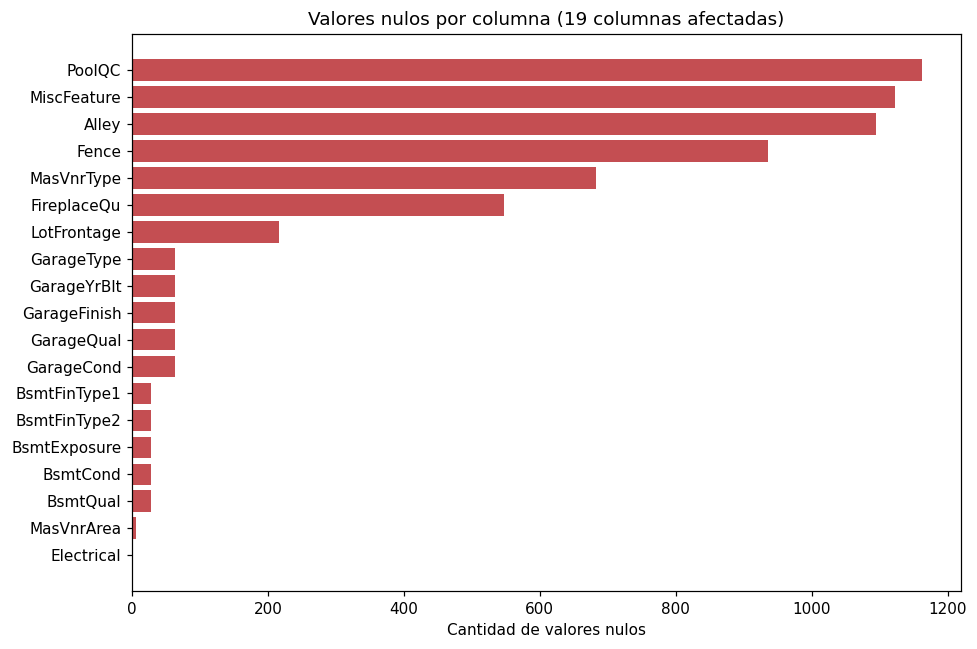

In [10]:
plt.figure(figsize=(9, 6))
plt.barh(nulls.index[::-1], nulls.values[::-1], color='#C44E52')
plt.xlabel('Cantidad de valores nulos')
plt.title(f'Valores nulos por columna ({len(nulls)} columnas afectadas)')
plt.tight_layout()
plt.show()

PoolQC, MiscFeature, Alley, Fence, FireplaceQu, GarageType/Finish/Qual/Cond,BsmtQual/Cond/Exposure/FinType1/FinType2, MasVnrType: el nulo significa ausencia de la característica, no un dato faltante real. Se imputarán como categoría "None".

LotFrontage: sí es un valor numérico faltante genuino. Se imputará con la mediana, ya que el frente del lote está muy relacionado con la zona.

MasVnrArea, GarageYrBlt, Electrical: pocos nulos, se imputan con mediana, moda o 0.

## 1.4	Distribuciones de variables, correlaciones entre features, relación de cada feature con la variable objetivo.

## 1.5	Decisiones de preprocesamiento derivadas del EDA y su justificación.